In [1]:
# torch import
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import sys
import os
import argparse
import matplotlib.pyplot as plt

sys.path.append(os.path.join(os.path.dirname("__file__"), ".."))
sys.path.append(os.path.join(os.path.dirname("__file__"), "../.."))


from fgsm_attack import FGSMAttack
from net.util import get_net
from repair.args import RepairArgs, RepairTask
from input_space.dataset import Dataset
from input_space.generate_input import clean_points

/Users/kotafukuda/Documents/Project_univ/repair/.venv/lib/python3.12/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3588.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Epsilon: 0.005	Attack Success Rate = 16 / 10000 = 0.0016


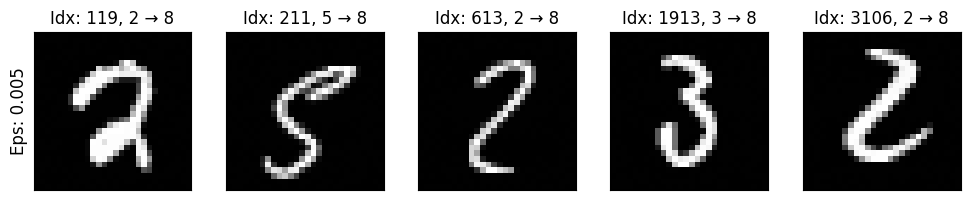

In [2]:
net_dataset_map = {
    0: ( "mnist 9x100", Dataset.MNIST ),
    1: ( "mnist_256x4", Dataset.MNIST ),
    2: ( "mnist_256x6", Dataset.MNIST ),
    3: ( "mnist_conv", Dataset.MNIST ),
    4: ( "cifar10_S", Dataset.CIFAR10 ),
    5: ( "cifar10_M", Dataset.CIFAR10 ),
    6: ( "cifar10_L", Dataset.CIFAR10 ),
}
net_dataset_index = 0
model_name, dataset = net_dataset_map[net_dataset_index]

experiment_mode = RepairTask.LocalRobustness

args = RepairArgs(repair_task=experiment_mode, model_name=model_name, dataset=dataset)

args.input_flatten, args.input_shape

net, _norm, _denorm = get_net(args, debug=False)

# epsilons = [0.1, 0.15, 0.2, 0.25, 0.3]
epsilons = [0.005]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = net.to(device)

# clean samples
clean_dataset = clean_points(args)
clean_loader = DataLoader(clean_dataset, batch_size=1, shuffle=False)

# attack
target = 8
fgsm_attack = FGSMAttack(args, model, epsilons, clean_loader, device, target)
fgsm_attack.run()

fgsm_attack.visualize()

In [9]:
adv_samples = fgsm_attack.adv_examples
print(len(adv_samples[0.1]))
adv_sample = adv_samples[0.1][0][2]
print(adv_sample.shape)

5
(28, 28)
